这个文档是追踪雨雷学长给数据的磁力线，看能否追踪到远超本身长度的磁力线

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav,loadmat
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

In [2]:
mat_data =loadmat(r'D:\Learning\PHD1st\magnetic_reconnecion\data\data_plasmoid.mat')
print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'B1', 'B2', 'B3', 'Gx', 'Gy', 'Gz', 'J1', 'J2', 'J3', 'Rho', 'T'])


In [3]:
b1=mat_data['B1']
b2=mat_data['B2']
b3=mat_data['B3']
gx=mat_data['Gx']
gy=mat_data['Gy']
gz=mat_data['Gz']

In [101]:
def trace_magnetic_line(start_point,gx,gy,gz,b1,b2,b3):
    import numpy as np
    from scipy.interpolate import RegularGridInterpolator
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    plt.rcParams["font.sans-serif"] = ["SimHei"]  # 使用黑体
    plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题
    interp_bx = RegularGridInterpolator((gx[0,:], gy[0,:], gz[0,:]), b1)
    interp_by = RegularGridInterpolator((gx[0,:], gy[0,:], gz[0,:]), b2)
    interp_bz = RegularGridInterpolator((gx[0,:], gy[0,:], gz[0,:]), b3)


    # 参数
    dl=np.sqrt(((gx.max()-gx.min())/193)**2 + ((gy.max()-gy.min())/193)**2 + ((gz.max()-gz.min())/96)**2)
    ds = 0.5*dl    # 步长 (格点单位)
    max_steps = 1000

    # 存轨迹
    trajectory = [start_point]

    # 跟踪磁力线
    current_point = start_point.copy()

    for _ in range(max_steps):
        
        try:
            # 当前点磁场值
            Bx = interp_bx(current_point)
            By = interp_by(current_point)
            Bz = interp_bz(current_point)
            B = np.array([Bx[0], By[0], Bz[0]])
            B_mag = np.linalg.norm(B)

            # 如果磁场强度太小就停止
            if B_mag == 0:

                break

            # 单位向量
            B_dir = B / B_mag

            # 前进一步
            next_point = current_point + B_dir * ds

            # 检查是否越界
            if (next_point[0] < gx.min() or next_point[0] > gx.max() or
                next_point[1] < gy.min() or next_point[1] > gy.max() or
                next_point[2] < gz.min() or next_point[2] > gz.max()):

                break

            # 存储轨迹点
            trajectory.append(next_point)
            current_point = next_point

        except ValueError:
            # 超出插值器范围

            break
    trajectory = np.array(trajectory)
    return trajectory

In [4]:
def trace_magnetic_line_bidirectional(start_point, gx, gy, gz, b1, b2, b3,max_steps):
    import numpy as np
    from scipy.interpolate import RegularGridInterpolator
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    plt.rcParams["font.sans-serif"] = ["SimHei"]
    plt.rcParams["axes.unicode_minus"] = False

    interp_bx = RegularGridInterpolator((gx[0, :], gy[0, :], gz[0, :]), b1)
    interp_by = RegularGridInterpolator((gx[0, :], gy[0, :], gz[0, :]), b2)
    interp_bz = RegularGridInterpolator((gx[0, :], gy[0, :], gz[0, :]), b3)

    dl = np.sqrt(((gx.max() - gx.min()) / 193) ** 2 + ((gy.max() - gy.min()) / 193) ** 2 + ((gz.max() - gz.min()) / 96) ** 2)
    ds = 0.5 * dl
    #max_steps = int(1e5)

    def trace_one_direction(start,direction):
        trajectory = [start]
        current_point = start.copy()
        for cnt in range(max_steps):
            try:
                Bx = interp_bx(current_point)
                By = interp_by(current_point)
                Bz = interp_bz(current_point)
                B = np.array([Bx[0], By[0], Bz[0]])
                B_mag = np.linalg.norm(B)

                if B_mag == 0:
                    break

                B_dir = B / B_mag
                next_point = current_point + direction * B_dir * ds

                if (next_point[0] < gx.min() or next_point[0] > gx.max() or
                    next_point[1] < gy.min() or next_point[1] > gy.max() or
                    next_point[2] < gz.min() or next_point[2] > gz.max()):
                    break

                trajectory.append(next_point)
                current_point = next_point

            except ValueError:
                break
        if cnt%10000 <1e-5:
            print(f"已完成{cnt/max_steps*10000:.2f}%")
        return np.array(trajectory)

    # 正向追踪
    traj_forward = trace_one_direction(start_point, direction=1)
    # 反向追踪
    traj_backward = trace_one_direction(start_point, direction=-1)

    # 拼接正反轨迹，中间点不重复
    full_trajectory = np.vstack((traj_backward[::-1][:-1], traj_forward))

    return full_trajectory


In [10]:
def plot_magnetic_line(start_point,trajectory,b):
    fig2=plt.figure(figsize=(6,6))
    plt.subplot(121)
    plt.imshow(b[:,100,:].T,origin='lower')
    plt.xlabel('x')
    plt.ylabel('z')
    plt.subplot(122)
    plt.imshow(b[:,:,50].T,origin='lower')
    plt.xlabel('x')
    plt.ylabel('y')

    fig=plt.figure(figsize=(12,12))
    ax1=fig.add_subplot(131)
    extent=[gx[0,0],gx[0,-1],gz[0,0],gz[0,-1]]
    ax1.imshow(b[:,100,:].T,extent=extent,origin='lower')
    ax1.plot(trajectory[:,0],trajectory[:,2],color='red')
    ax1.scatter(start_point[0], start_point[2], color='red',marker='*')
    ax1.scatter(trajectory[-1,0], trajectory[-1,2], color='green',marker='*')
    ax1.set_xlabel('x')
    ax1.set_ylabel('z')
    ax2=fig.add_subplot(132)
    extent=[gx[0,0],gx[0,-1],gy[0,0],gy[0,-1]]
    ax2.imshow(b[:,:,50].T,extent=extent,origin='lower')
    ax2.plot(trajectory[:,0],trajectory[:,1],color='red')
    ax2.scatter(start_point[0], start_point[1], color='red',marker='*')
    ax2.scatter(trajectory[-1,0], trajectory[-1,1], color='green',marker='*')
    ax2.set_xlabel('x') 
    ax2.set_ylabel('y')
    ax3= fig.add_subplot(133, projection='3d')
    ax3.plot(trajectory[:,0], trajectory[:,1], trajectory[:,2], color='blue')
    ax3.scatter(start_point[0], start_point[1], start_point[2], color='red',marker='*')
    ax3.plot(trajectory[-1,0], trajectory[-1,1], trajectory[-1,2], color='green',marker='*')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_zlabel('Z')



In [69]:
dl=np.sqrt(((gx.max()-gx.min())/193)**2 + ((gy.max()-gy.min())/193)**2 + ((gz.max()-gz.min())/96)**2)
ds=0.5*dl
print(ds)

0.0004479321230180697


10097


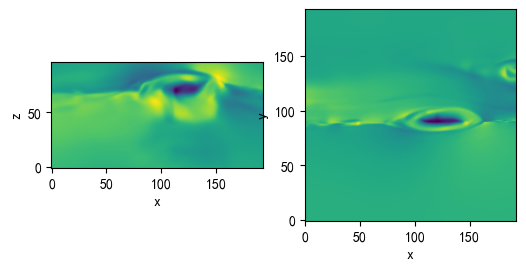

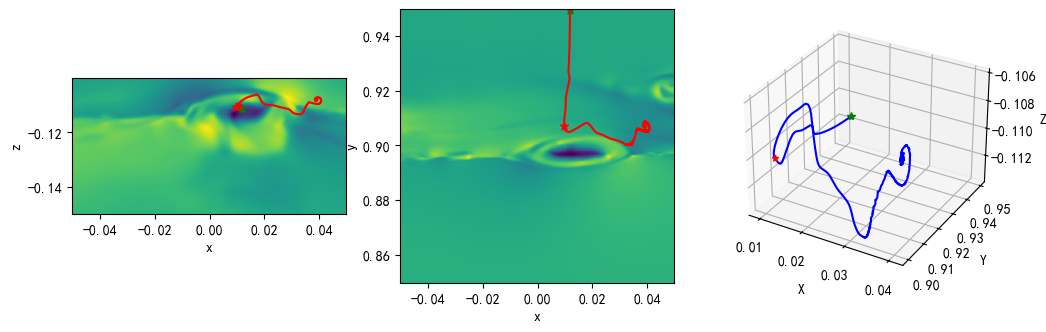

In [11]:
# 绘制磁力线
#[gx[0,115],gy[0,120],gz[0,75]]这个点磁力线会一直卡死在里面
start_point = np.array([gx[0,115],gy[0,110],gz[0,75]])
trajectory=trace_magnetic_line_bidirectional(start_point,gx,gy,gz,b1,b2,b3,int(1e4))
print(len(trajectory))
plot_magnetic_line(start_point,trajectory,b3)

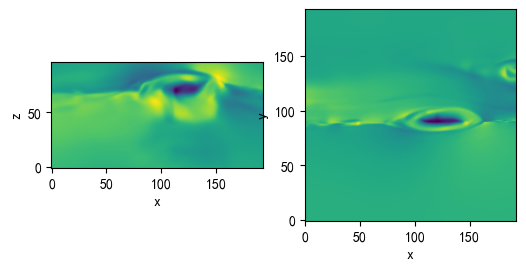

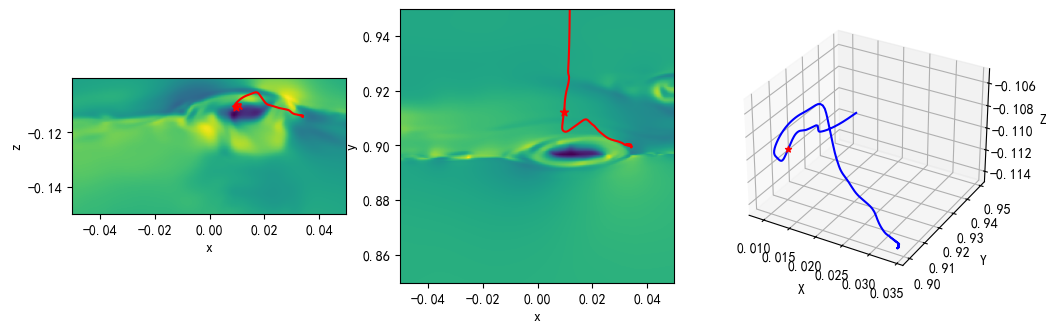

In [121]:
# 绘制磁力线
start_point = np.array([gx[0,115],gy[0,120],gz[0,75]])
trajectory=trace_magnetic_line_bidirectional(start_point,gx,gy,gz,b1,b2,b3,int(2*1e5))
plot_magnetic_line(start_point,trajectory,b3)

In [28]:
print(gx.min(),gx.max())
print(gy.min(),gy.max())
print(gz.min(),gz.max())

-0.05026041716337204 0.04973958432674408
0.8497395515441895 0.9497395753860474
-0.1497395932674408 -0.1002604216337204
